# 12-1 모멘텀 전략 백테스트 (생존 편향 제거 버전)

기존 코드는 `fdr.StockListing('KOSPI')`으로 **현재 시점**의 시총 상위 50개를 뽑아 과거 전체에 적용했기 때문에
생존 편향(survivorship bias)과 미래참조 편향(look-ahead bias)이 있었습니다.

이 버전은 [FinanceData/marcap](https://github.com/FinanceData/marcap) 데이터셋(상장폐지 종목 포함, 1995~현재 일별 시가총액)을 사용해:

1. **매월 말, 그 시점에 실제 존재했던 종목 중 시총 상위 50개**를 유니버스로 다시 구성 (point-in-time)
2. 상장폐지·거래정지 종목도 마지막 거래일까지 데이터에 포함
3. marcap의 종가는 무수정 주가이므로 **액면분할/병합을 주식수 변화로 감지해 수익률 보정**
4. 기존 코드의 버그 수정: 양수 모멘텀 종목이 10개 미만인 달은 건너뛰지 않고 **현금 보유(수익률 0%)** 로 처리


In [1]:
# 0) 설치: marcap 데이터셋 클론 (약 1GB, 1~2분 소요) + 벤치마크용 FDR
!git clone --depth 1 https://github.com/FinanceData/marcap.git marcap
!pip install -q finance-datareader

Cloning into 'marcap'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 43 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 438.39 MiB | 11.57 MiB/s, done.
Updating files: 100% (38/38), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from marcap import marcap_data

# 1) 데이터 로드
# 전략 기간 2020-01 ~ 2024-12, 12개월 lookback 확보를 위해 2018-12부터 로드
raw = marcap_data('2018-12-01', '2024-12-31')

# 코스피 보통주/우선주만 사용 (marcap_data는 거래량 0인 날을 이미 제외함)
kospi = raw[raw['Market'] == 'KOSPI'].reset_index()
print(f"일별 레코드: {kospi.shape}, 종목 수: {kospi['Code'].nunique()}")

일별 레코드: (1374274, 18), 종목 수: 1016


In [3]:
# 2) 월말 스냅샷 패널 만들기
# 종목별로 각 월의 '마지막 거래일' 레코드를 사용
# → 상장폐지/거래정지 종목은 마지막 거래 가능일까지의 가격이 자동 반영됨
kospi['YM'] = kospi['Date'].dt.to_period('M')
kospi = kospi.sort_values('Date')
snap = kospi.groupby(['YM', 'Code'], as_index=False).last()

close_m  = snap.pivot(index='YM', columns='Code', values='Close')   # 월말 종가 (무수정)
stocks_m = snap.pivot(index='YM', columns='Code', values='Stocks')  # 상장주식수
marcap_m = snap.pivot(index='YM', columns='Code', values='Marcap')  # 시가총액

print(f"월말 패널: {close_m.shape}  (월수, 전체 등장 종목수)")

월말 패널: (73, 1016)  (월수, 전체 등장 종목수)


In [4]:
# 3) 분할 조정 월간 수익률
# marcap의 Close는 무수정 주가 → 액면분할/병합이 있으면 가격이 크게 점프함
# 주식수가 한 달 새 ±50% 넘게 바뀌면 분할/병합으로 간주하고 주식수 비율로 가격을 보정
# (예: 5:1 분할 → 가격 1/5, 주식수 5배 → 곱하면 실제 수익률 복원)
# 주의: 유상증자 등 소폭 주식수 변화는 보정하지 않음(가격 자체가 수익률에 가깝기 때문)
price_ratio  = close_m / close_m.shift(1)
stocks_ratio = stocks_m / stocks_m.shift(1)

split_like = (stocks_ratio > 1.5) | (stocks_ratio < 1/1.5)
adj_ratio  = price_ratio.where(~split_like, price_ratio * stocks_ratio)
monthly_returns = adj_ratio - 1

print(f"분할/병합 보정 적용 건수: {int(split_like.sum().sum())}")

분할/병합 보정 적용 건수: 217


In [5]:
# 4) 12-1 모멘텀 계산 (t-12월말 ~ t-1월말 누적수익률, 최근 1개월 제외)
# 조정 수익률 기반이므로 분할 종목도 왜곡 없이 계산됨
log_r = np.log(adj_ratio)
momentum_df = np.exp(log_r.shift(1).rolling(11).sum()) - 1

print(momentum_df.shape)

(73, 1016)


In [6]:
# 5) 백테스트: 생존 편향 제거의 핵심
# 매월 말(t)에 '그 시점' 시총 상위 50개를 유니버스로 새로 구성한 뒤
# 그 안에서 양수 모멘텀 상위 10종목을 동일비중 매수, 다음 달(t+1) 수익률 실현
months  = close_m.index
start_i = list(months).index(pd.Period('2019-12'))  # 첫 보유월 = 2020-01

rows, holdings_log = [], {}
for i in range(start_i, len(months) - 1):
    t, nxt = months[i], months[i + 1]

    # ★ point-in-time 유니버스: t 시점 시총 상위 50 (미래 정보 사용 안 함)
    univ = marcap_m.loc[t].dropna().nlargest(50).index

    scores = momentum_df.loc[t, univ].dropna()
    scores = scores[scores > 0]                    # 절대 모멘텀 필터

    if len(scores) < 10:
        # 기존 코드는 continue로 그 달을 통째로 누락시켰음 → 현금 보유(0%)로 수정
        rows.append({'date': nxt, 'return': 0.0, 'n_held': 0})
        continue

    top10 = scores.nlargest(10).index
    holdings_log[str(nxt)] = list(top10)

    r = monthly_returns.loc[nxt, top10]
    # 보유 중 거래정지 등으로 다음 달 수익률이 없는 종목은 0%(원금 보전) 가정 — 보수적 처리
    rows.append({'date': nxt, 'return': r.fillna(0).mean(), 'n_held': len(top10)})

strategy_df = pd.DataFrame(rows).set_index('date')
print(f"전략 기간: {strategy_df.index[0]} ~ {strategy_df.index[-1]}, 총 {len(strategy_df)}개월")
print(f"현금 보유월: {(strategy_df['n_held'] == 0).sum()}개월")

전략 기간: 2020-01 ~ 2024-12, 총 60개월
현금 보유월: 4개월


In [7]:
# 생존 편향이 실제로 얼마나 컸는지 확인
u_start = set(marcap_m.loc[pd.Period('2020-01')].dropna().nlargest(50).index)
u_end   = set(marcap_m.loc[pd.Period('2024-11')].dropna().nlargest(50).index)
print(f"2020-01 시총상위50 vs 2024-11 시총상위50 겹침: {len(u_start & u_end)}개 / 50개")
print("→ 고정 유니버스를 쓰면 이 차이만큼 미래 정보가 새어 들어감")

# 최근 보유 종목 확인
names = kospi.drop_duplicates('Code', keep='last').set_index('Code')['Name']
last = sorted(holdings_log)[-1]
print(f"\n{last} 보유: {[names.get(c, c) for c in holdings_log[last]]}")

2020-01 시총상위50 vs 2024-11 시총상위50 겹침: 33개 / 50개
→ 고정 유니버스를 쓰면 이 차이만큼 미래 정보가 새어 들어감

2024-12 보유: ['HD현대일렉트릭', '한화에어로스페이스', '유한양행', '고려아연', '메리츠금융지주', 'KB금융', 'SK스퀘어', 'HD한국조선해양', '크래프톤', 'HD현대중공업']


In [8]:
# 6) 벤치마크: KOSPI200 지수
import FinanceDataReader as fdr

ks200 = fdr.DataReader('KS200', '2019-12-01', '2024-12-31')['Close']
ks200_monthly = ks200.resample('ME').last().pct_change()
ks200_monthly.index = ks200_monthly.index.to_period('M')
bm = ks200_monthly.reindex(strategy_df.index)

In [9]:
# 7) 성과 지표
def performance_summary(returns, name="전략"):
    r = pd.Series(returns).dropna()
    cagr     = (1 + r).prod() ** (12 / len(r)) - 1
    sharpe   = r.mean() / r.std() * np.sqrt(12)
    cum      = (1 + r).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    win_rate = (r > 0).mean()

    print(f"{'='*32}")
    print(f"  [{name}]")
    print(f"  CAGR     : {cagr:>8.1%}")
    print(f"  Sharpe   : {sharpe:>8.2f}")
    print(f"  MDD      : {mdd:>8.1%}")
    print(f"  월 승률   : {win_rate:>8.1%}")
    print(f"{'='*32}")

performance_summary(strategy_df['return'], "모멘텀 전략 (생존편향 제거)")
performance_summary(bm, "KOSPI200 BM")

  [모멘텀 전략 (생존편향 제거)]
  CAGR     :     5.9%
  Sharpe   :     0.35
  MDD      :   -45.2%
  월 승률   :    46.7%
  [KOSPI200 BM]
  CAGR     :     1.6%
  Sharpe   :     0.18
  MDD      :   -35.9%
  월 승률   :    50.0%


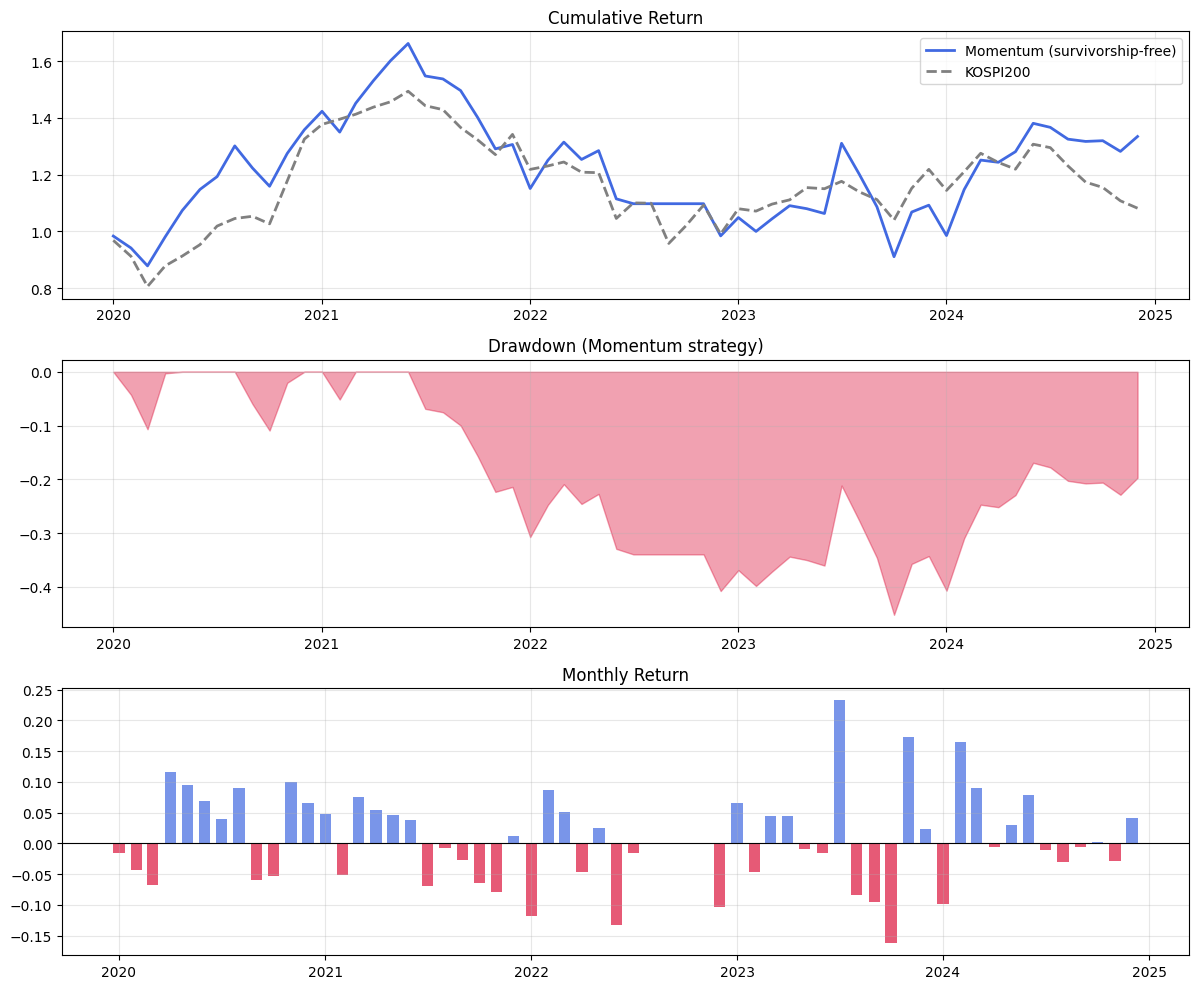

In [10]:
# 8) 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
idx = strategy_df.index.to_timestamp()

cum_strategy = (1 + strategy_df['return']).cumprod()
cum_bm       = (1 + bm.fillna(0)).cumprod()

axes[0].plot(idx, cum_strategy, label='Momentum (survivorship-free)', linewidth=2, color='royalblue')
axes[0].plot(idx, cum_bm, label='KOSPI200', linewidth=2, color='gray', linestyle='--')
axes[0].set_title('Cumulative Return')
axes[0].legend(); axes[0].grid(alpha=0.3)

rolling_max = cum_strategy.cummax()
drawdown = (cum_strategy - rolling_max) / rolling_max
axes[1].fill_between(idx, drawdown, 0, alpha=0.4, color='crimson')
axes[1].set_title('Drawdown (Momentum strategy)'); axes[1].grid(alpha=0.3)

colors = ['royalblue' if r >= 0 else 'crimson' for r in strategy_df['return']]
axes[2].bar(idx, strategy_df['return'], color=colors, alpha=0.7, width=20)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Monthly Return'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 남아 있는 한계

생존 편향은 제거됐지만 다음은 여전히 반영되지 않았습니다:

- **거래비용 미반영** — 매월 리밸런싱 회전율을 고려하면 수수료·증권거래세·슬리피지로 연 수익률이 수 %p 깎일 수 있음
- **분할 보정은 휴리스틱** — 주식수 ±50% 기준이라 대규모 유상증자(예: 무상증자 100%)를 분할로 오인하거나, 배당락은 보정하지 못함. 정확한 총수익률(TR)에는 배당 재투자가 빠져 있어 실제보다 약간 과소평가됨
- **월말 종가 체결 가정** — 실제로는 다음 거래일 시가 체결에 가까움
- **표본 기간 5년** — 코로나 급락·반등이 포함된 특수 구간이라 일반화에 주의
